## 1. Carga de los datasets

In [12]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN


df1_expo_pais = pd.read_csv('../data/raw/1-expo_CEPII_BACI_mineras_mundiales_pais.csv')
df2_comex_sector_grupo = pd.read_csv('../data/raw/2-comex_CEPII_BACI_mineras_mundiales_sector_grupo.csv')
df3_expo_porcentajes_pais = pd.read_csv('../data/raw/3-expo_CEPII_BACI_mineras_mundiales_porcentajes_pais.csv')
df4_expominerales_siacam = pd.read_csv('../data/raw/4-expominerales-siacam.csv')

## 2. Analisis exploratorio de datos


#### df1_expo_pais: Exportaciones mineras mundiales por país

In [13]:
print('Información de df1_expo_pais:')
display(df1_expo_pais.info())
print('\nDescripción estadística de df1_expo_pais:')
display(df1_expo_pais.describe(include='all'))

Información de df1_expo_pais:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6536 entries, 0 to 6535
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   year             6536 non-null   int64  
 1   pais_exportador  6536 non-null   object 
 2   value            6536 non-null   float64
dtypes: float64(1), int64(1), object(1)
memory usage: 153.3+ KB


None


Descripción estadística de df1_expo_pais:


,year,pais_exportador,value
count,6536.000000,6536,6536.000000
unique,NaN,232,NaN
top,NaN,Estados Unidos,NaN
freq,NaN,30,NaN
mean,2009.730722,NaN,2918.318564
std,8.597237,NaN,9827.799552
min,1995.000000,NaN,0.000003
25%,2002.000000,NaN,5.139782
50%,2010.000000,NaN,182.449338
75%,2017.000000,NaN,1492.929871


#### df2_comex_sector_grupo: Comercio minero mundial por sector y grupo

In [14]:
print('Información de df2_comex_sector_grupo:')
display(df2_comex_sector_grupo.info())
print('\nDescripción estadística de df2_comex_sector_grupo:')
display(df2_comex_sector_grupo.describe(include='all'))

Información de df2_comex_sector_grupo:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2667 entries, 0 to 2666
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   year    2667 non-null   int64  
 1   sector  2667 non-null   object 
 2   grupo   2667 non-null   object 
 3   value   2667 non-null   float64
dtypes: float64(1), int64(1), object(2)
memory usage: 83.5+ KB


None


Descripción estadística de df2_comex_sector_grupo:


,year,sector,grupo,value
count,2667.000000,2667,2667,2667.000000
unique,NaN,5,88,NaN
top,NaN,No metaliferos,Magnesio,NaN
freq,NaN,990,60,NaN
mean,2009.494188,NaN,NaN,7151.904811
std,8.660095,NaN,NaN,31219.844207
min,1995.000000,NaN,NaN,0.000478
25%,2002.000000,NaN,NaN,274.611653
50%,2009.000000,NaN,NaN,840.027367
75%,2017.000000,NaN,NaN,2548.032921


#### df3_expo_porcentajes_pais: Porcentaje de participación en exportaciones mineras por país

In [15]:
print('Información de df3_expo_porcentajes_pais:')
display(df3_expo_porcentajes_pais.info())
print('\nDescripción estadística de df3_expo_porcentajes_pais:')
display(df3_expo_porcentajes_pais.describe(include='all'))

Información de df3_expo_porcentajes_pais:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6536 entries, 0 to 6535
Data columns (total 3 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   year                      6536 non-null   int64  
 1   pais_exportador           6536 non-null   object 
 2   Porcentaje_Participacion  6536 non-null   float64
dtypes: float64(1), int64(1), object(1)
memory usage: 153.3+ KB


None


Descripción estadística de df3_expo_porcentajes_pais:


,year,pais_exportador,Porcentaje_Participacion
count,6536.000000,6536,6.536000e+03
unique,NaN,232,NaN
top,NaN,Afganistán,NaN
freq,NaN,30,NaN
mean,2009.730722,NaN,4.589963e-01
std,8.597237,NaN,1.254034e+00
min,1995.000000,NaN,3.225047e-10
25%,2002.000000,NaN,1.307053e-03
50%,2010.000000,NaN,4.076900e-02
75%,2017.000000,NaN,2.712856e-01


#### df4_expominerales_siacam: Datos de expominerales (SIACAM)

In [16]:
print('Información de df4_expominerales_siacam:')
display(df4_expominerales_siacam.info())
print('\nDescripción estadística de df4_expominerales_siacam:')
display(df4_expominerales_siacam.describe(include='all'))

Información de df4_expominerales_siacam:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17558 entries, 0 to 17557
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   ANYO    17558 non-null  int64  
 1   MES     17558 non-null  int64  
 2   GRUPO   17558 non-null  object 
 3   SECTOR  17558 non-null  object 
 4   FOB     17558 non-null  float64
dtypes: float64(1), int64(2), object(2)
memory usage: 686.0+ KB


None


Descripción estadística de df4_expominerales_siacam:


,ANYO,MES,GRUPO,SECTOR,FOB
count,17558.000000,17558.000000,17558,17558,1.755800e+04
unique,NaN,NaN,95,5,NaN
top,NaN,NaN,Cales,No metaliferos,NaN
freq,NaN,NaN,387,8167,NaN
mean,2008.083779,6.537191,NaN,NaN,4.854755e+06
std,8.307511,3.452583,NaN,NaN,2.572463e+07
min,1994.000000,1.000000,NaN,NaN,0.000000e+00
25%,2001.000000,4.000000,NaN,NaN,8.755250e+03
50%,2008.000000,7.000000,NaN,NaN,5.719300e+04
75%,2014.000000,10.000000,NaN,NaN,3.891625e+05


## 3. Preprocesamiento de datos

#### Conversión de tipos de datos y manejo de valores nulos



Basado en la inspección inicial, convertiremos las columnas de `year`/`ANYO` a tipo entero y las columnas de `value`/`FOB`/`Porcentaje_Participacion` a tipo numérico (float) para asegurar la compatibilidad y facilitar los análisis. También abordaremos posibles valores nulos si aparecen.

In [17]:
# Convertir 'year' a entero y 'value' a numérico en df1_expo_pais
df1_expo_pais['year'] = pd.to_numeric(df1_expo_pais['year'], errors='coerce').astype('Int64')
df1_expo_pais['value'] = pd.to_numeric(df1_expo_pais['value'], errors='coerce')

# Convertir 'year' a entero y 'value' a numérico en df2_comex_sector_grupo
df2_comex_sector_grupo['year'] = pd.to_numeric(df2_comex_sector_grupo['year'], errors='coerce').astype('Int64')
df2_comex_sector_grupo['value'] = pd.to_numeric(df2_comex_sector_grupo['value'], errors='coerce')

# Convertir 'year' a entero y 'Porcentaje_Participacion' a numérico en df3_expo_porcentajes_pais
df3_expo_porcentajes_pais['year'] = pd.to_numeric(df3_expo_porcentajes_pais['year'], errors='coerce').astype('Int64')
df3_expo_porcentajes_pais['Porcentaje_Participacion'] = pd.to_numeric(df3_expo_porcentajes_pais['Porcentaje_Participacion'], errors='coerce')

# Convertir 'ANYO', 'MES' a entero y 'FOB' a numérico en df4_expominerales_siacam
df4_expominerales_siacam['ANYO'] = pd.to_numeric(df4_expominerales_siacam['ANYO'], errors='coerce').astype('Int64')
df4_expominerales_siacam['MES'] = pd.to_numeric(df4_expominerales_siacam['MES'], errors='coerce').astype('Int64')
df4_expominerales_siacam['FOB'] = pd.to_numeric(df4_expominerales_siacam['FOB'], errors='coerce')

print('\nValores nulos después de la conversión de tipos:')
print('df1_expo_pais nulos:\n', df1_expo_pais.isnull().sum())
print('df2_comex_sector_grupo nulos:\n', df2_comex_sector_grupo.isnull().sum())
print('df3_expo_porcentajes_pais nulos:\n', df3_expo_porcentajes_pais.isnull().sum())
print('df4_expominerales_siacam nulos:\n', df4_expominerales_siacam.isnull().sum())


Valores nulos después de la conversión de tipos:
df1_expo_pais nulos:
 year               0
pais_exportador    0
value              0
dtype: int64
df2_comex_sector_grupo nulos:
 year      0
sector    0
grupo     0
value     0
dtype: int64
df3_expo_porcentajes_pais nulos:
 year                        0
pais_exportador             0
Porcentaje_Participacion    0
dtype: int64
df4_expominerales_siacam nulos:
 ANYO      0
MES       0
GRUPO     0
SECTOR    0
FOB       0
dtype: int64


#### Detección y eliminación de duplicados

En este paso, convertimos los tipos de datos de las columnas numéricas. La opción `errors='coerce'` reemplazará cualquier valor que no se pueda convertir a numérico con `NaN` (Not a Number), lo que nos permite identificar y manejar estos casos. Luego, `astype('Int64')` se usa para permitir valores nulos en columnas enteras.

In [18]:
print('Duplicados antes de la eliminación:')
print('df1_expo_pais duplicados:', df1_expo_pais.duplicated().sum())
print('df2_comex_sector_grupo duplicados:', df2_comex_sector_grupo.duplicated().sum())
print('df3_expo_porcentajes_pais duplicados:', df3_expo_porcentajes_pais.duplicated().sum())
print('df4_expominerales_siacam duplicados:', df4_expominerales_siacam.duplicated().sum())

df1_expo_pais.drop_duplicates(inplace=True)
df2_comex_sector_grupo.drop_duplicates(inplace=True)
df3_expo_porcentajes_pais.drop_duplicates(inplace=True)
df4_expominerales_siacam.drop_duplicates(inplace=True)

print('\nDuplicados después de la eliminación:')
print('df1_expo_pais duplicados:', df1_expo_pais.duplicated().sum())
print('df2_comex_sector_grupo duplicados:', df2_comex_sector_grupo.duplicated().sum())
print('df3_expo_porcentajes_pais duplicados:', df3_expo_porcentajes_pais.duplicated().sum())
print('df4_expominerales_siacam duplicados:', df4_expominerales_siacam.duplicated().sum())

Duplicados antes de la eliminación:
df1_expo_pais duplicados: 0
df2_comex_sector_grupo duplicados: 0
df3_expo_porcentajes_pais duplicados: 0
df4_expominerales_siacam duplicados: 0

Duplicados después de la eliminación:
df1_expo_pais duplicados: 0
df2_comex_sector_grupo duplicados: 0
df3_expo_porcentajes_pais duplicados: 0
df4_expominerales_siacam duplicados: 0


#### Análisis de Variables Categóricas y Unicidad de Valores

El análisis de `value_counts()` para las columnas categóricas nos da una visión de la distribución de los valores y nos ayuda a identificar si existen categorías con muy pocos registros, errores tipográficos, o si es necesario agrupar ciertas categorías para simplificar el análisis.

In [19]:
print('''--- df1_expo_pais: pais_exportador ---
''', df1_expo_pais['pais_exportador'].value_counts())

print('''
--- df2_comex_sector_grupo: sector ---
''', df2_comex_sector_grupo['sector'].value_counts())
print('''
--- df2_comex_sector_grupo: grupo ---
''', df2_comex_sector_grupo['grupo'].value_counts())

print('''
--- df3_expo_porcentajes_pais: pais_exportador ---
''', df3_expo_porcentajes_pais['pais_exportador'].value_counts())

print('''
--- df4_expominerales_siacam: GRUPO ---
''', df4_expominerales_siacam['GRUPO'].value_counts())
print('''
--- df4_expominerales_siacam: SECTOR ---
''', df4_expominerales_siacam['SECTOR'].value_counts())

--- df1_expo_pais: pais_exportador ---
 pais_exportador
Estados Unidos                  30
Canadá                          30
Australia                       30
Chile                           30
Federación de Rusia             30
                                ..
San Barthélemy                  11
Serbia y Montenegro             11
Sudán del Sur                   10
Unión Ad. del África Austral     5
EE.UU. Islas del Pacífico        5
Name: count, Length: 232, dtype: int64

--- df2_comex_sector_grupo: sector ---
 sector
No metaliferos                         990
Metaliferos                            960
Rocas de aplicacion                    657
Combustibles                            30
Piedras preciosas y/o semipreciosas     30
Name: count, dtype: int64

--- df2_comex_sector_grupo: grupo ---
 grupo
Magnesio                            60
Hullas                              30
Aluminio y bauxita                  30
Aluminio                            30
Arenas de escorias de siderur

#### Estandarización y limpieza de variables categóricas

In [20]:
# Función para estandarizar nombres de países
def standardize_country_name(country):
    if isinstance(country, str):
        country = country.strip().title()
        # Corregir variantes comunes
        if 'estados unidos' in country.lower():
            return 'Estados Unidos'
        if 'reino unido' in country.lower():
            return 'Reino Unido'
        if 'federacion de rusia' in country.lower():
            return 'Rusia'
        if 'china' in country.lower():
            return 'China'
        if 'corea' in country.lower():
            return 'Corea del Sur' # Asumiendo Corea del Sur por ser el principal socio comercial
        if 'alemania' in country.lower():
            return 'Alemania'
        if 'japon' in country.lower():
            return 'Japón'
        if 'india' in country.lower():
            return 'India'
        if 'brasil' in country.lower():
            return 'Brasil'
        if 'australia' in country.lower():
            return 'Australia'
        if 'canada' in country.lower():
            return 'Canadá'
        if 'mexico' in country.lower():
            return 'México'
        if 'chile' in country.lower():
            return 'Chile'
        if 'peru' in country.lower():
            return 'Perú'
        if 'argentina' in country.lower():
            return 'Argentina'
        if 'colombia' in country.lower():
            return 'Colombia'
        if 'sudafrica' in country.lower():
            return 'Sudáfrica'
        if 'indonesia' in country.lower():
            return 'Indonesia'
        if 'arabia saudita' in country.lower():
            return 'Arabia Saudita'
        if 'emiratos arabes unidos' in country.lower():
            return 'Emiratos Árabes Unidos'
        if 'suiza' in country.lower():
            return 'Suiza'
        if 'noruega' in country.lower():
            return 'Noruega'
        if 'suecia' in country.lower():
            return 'Suecia'
        if 'finlandia' in country.lower():
            return 'Finlandia'
        if 'francia' in country.lower():
            return 'Francia'
        if 'italia' in country.lower():
            return 'Italia'
        if 'espana' in country.lower():
            return 'España'
        if 'paises bajos' in country.lower():
            return 'Países Bajos'
        if 'belgica' in country.lower():
            return 'Bélgica'
        if 'austria' in country.lower():
            return 'Austria'
        if 'polonia' in country.lower():
            return 'Polonia'
        if 'turquia' in country.lower():
            return 'Turquía'
        if 'egipto' in country.lower():
            return 'Egipto'
        if 'nigeria' in country.lower():
            return 'Nigeria'
        if 'iran' in country.lower():
            return 'Irán'
        if 'pakistan' in country.lower():
            return 'Pakistán'
        if 'vietnam' in country.lower():
            return 'Vietnam'
        if 'malasia' in country.lower():
            return 'Malasia'
        if 'filipinas' in country.lower():
            return 'Filipinas'
        if 'tailandia' in country.lower():
            return 'Tailandia'
        if 'nueva zelanda' in country.lower():
            return 'Nueva Zelanda'
        if 'cuba' in country.lower():
            return 'Cuba'
        if 'venezuela' in country.lower():
            return 'Venezuela'
        if 'bolivia' in country.lower():
            return 'Bolivia'
        if 'ecuador' in country.lower():
            return 'Ecuador'
        if 'paraguay' in country.lower():
            return 'Paraguay'
        if 'uruguay' in country.lower():
            return 'Uruguay'
        if 'costa rica' in country.lower():
            return 'Costa Rica'
        if 'panama' in country.lower():
            return 'Panamá'
        if 'guatemala' in country.lower():
            return 'Guatemala'
        if 'honduras' in country.lower():
            return 'Honduras'
        if 'el salvador' in country.lower():
            return 'El Salvador'
        if 'nicaragua' in country.lower():
            return 'Nicaragua'
        if 'republica dominicana' in country.lower():
            return 'República Dominicana'
        if 'puerto rico' in country.lower():
            return 'Puerto Rico'
        if 'jamaica' in country.lower():
            return 'Jamaica'
        if 'trinidad y tobago' in country.lower():
            return 'Trinidad y Tobago'
        if 'israel' in country.lower():
            return 'Israel'
        if 'egipto' in country.lower():
            return 'Egipto'
        if 'marruecos' in country.lower():
            return 'Marruecos'
        if 'argelia' in country.lower():
            return 'Argelia'
        if 'tunisia' in country.lower():
            return 'Túnez'
        if 'libia' in country.lower():
            return 'Libia'
        if 'etiopia' in country.lower():
            return 'Etiopía'
        if 'kenia' in country.lower():
            return 'Kenia'
        if 'tanzania' in country.lower():
            return 'Tanzania'
        if 'uganda' in country.lower():
            return 'Uganda'
        if 'ruanda' in country.lower():
            return 'Ruanda'
        if 'angola' in country.lower():
            return 'Angola'
        if 'mozambique' in country.lower():
            return 'Mozambique'
        if 'madagascar' in country.lower():
            return 'Madagascar'
        if 'sri lanka' in country.lower():
            return 'Sri Lanka'
        if 'bangladesh' in country.lower():
            return 'Bangladés'
        if 'pakistan' in country.lower():
            return 'Pakistán'
        if 'afganistan' in country.lower():
            return 'Afganistán'
        if 'siria' in country.lower():
            return 'Siria'
        if 'irak' in country.lower():
            return 'Irak'
        if 'jordan' in country.lower():
            return 'Jordania'
        if 'libano' in country.lower():
            return 'Líbano'
        if 'kuwait' in country.lower():
            return 'Kuwait'
        if 'qatar' in country.lower():
            return 'Qatar'
        if 'bahrein' in country.lower():
            return 'Baréin'
        if 'oman' in country.lower():
            return 'Omán'
        if 'yemen' in country.lower():
            return 'Yemen'
        if 'grecia' in country.lower():
            return 'Grecia'
        if 'portugal' in country.lower():
            return 'Portugal'
        if 'irlanda' in country.lower():
            return 'Irlanda'
        if 'islandia' in country.lower():
            return 'Islandia'
        if 'dinamarca' in country.lower():
            return 'Dinamarca'
        if 'nueva caledonia' in country.lower():
            return 'Nueva Caledonia'
        if 'filipinas' in country.lower():
            return 'Filipinas'
        if 'singapur' in country.lower():
            return 'Singapur'
        if 'hong kong' in country.lower():
            return 'Hong Kong'
        if 'taiwan' in country.lower():
            return 'Taiwán'
        if 'corea del norte' in country.lower():
            return 'Corea del Norte'
        # Casos especiales de los datos
        if 'unión ad. del áfrica austral' in country.lower():
            return 'Unión Aduanera del África Austral'
        if 'san barthélemy' in country.lower():
            return 'San Bartolomé'
        if 'serbia y montenegro' in country.lower():
            return 'Serbia y Montenegro'
        if 'ee.uu. islas del pacífico' in country.lower():
            return 'Islas del Pacífico de EE.UU.'
        if 'sudán del sur' in country.lower():
            return 'Sudán del Sur'
    return country

# Aplicar la estandarización a df1_expo_pais y df3_expo_porcentajes_pais
df1_expo_pais['pais_exportador'] = df1_expo_pais['pais_exportador'].apply(standardize_country_name)
df3_expo_porcentajes_pais['pais_exportador'] = df3_expo_porcentajes_pais['pais_exportador'].apply(standardize_country_name)

print('--- df1_expo_pais: pais_exportador (Después de estandarización) ---',
      df1_expo_pais['pais_exportador'].value_counts())
print('\n--- df3_expo_porcentajes_pais: pais_exportador (Después de estandarización) ---',
      df3_expo_porcentajes_pais['pais_exportador'].value_counts())

--- df1_expo_pais: pais_exportador (Después de estandarización) --- pais_exportador
Corea del Sur                        60
China                                60
Australia                            30
Chile                                30
Estados Unidos                       30
                                     ..
San Bartolomé                        11
Serbia y Montenegro                  11
Sudán del Sur                        10
Unión Aduanera del África Austral     5
Islas del Pacífico de EE.UU.          5
Name: count, Length: 230, dtype: int64

--- df3_expo_porcentajes_pais: pais_exportador (Después de estandarización) --- pais_exportador
China                                60
Corea del Sur                        60
Alemania                             30
Andorra                              30
Angola                               30
                                     ..
San Bartolomé                        11
Serbia y Montenegro                  11
Sudán del Sur       

#### Estandarización de `sector` y `grupo`

In [21]:
# Estandarizar la columna 'sector' en df2_comex_sector_grupo
df2_comex_sector_grupo['sector'] = df2_comex_sector_grupo['sector'].str.strip().str.lower().replace({
    'no metaliferos': 'no metalíferos',
    'rocas de aplicacion': 'rocas de aplicación'
})

# Estandarizar la columna 'grupo' en df2_comex_sector_grupo
df2_comex_sector_grupo['grupo'] = df2_comex_sector_grupo['grupo'].str.strip().str.lower().replace({
    'aluminio y bauxita': 'aluminio',
    'arenas de escorias de siderurgia': 'arenas de siderurgia',
    'mármoles y travertinos': 'mármoles y travertinos',
    'piedras talladas o aserradas': 'piedras talladas',
    'triturados pétreos': 'triturados pétreos',
    'hullas': 'carbón'
})

# Estandarizar la columna 'SECTOR' en df4_expominerales_siacam
df4_expominerales_siacam['SECTOR'] = df4_expominerales_siacam['SECTOR'].str.strip().str.lower().replace({
    'no metaliferos': 'no metalíferos',
    'rocas de aplicacion': 'rocas de aplicación',
    'piedras preciosas y/o semipreciosas': 'piedras preciosas'
})

# Estandarizar la columna 'GRUPO' en df4_expominerales_siacam
df4_expominerales_siacam['GRUPO'] = df4_expominerales_siacam['GRUPO'].str.strip().str.lower().replace({
    'sales': 'sal',
    'piedras lajas': 'piedras lajas',
    'triturados petreos': 'triturados pétreos',
    'arcillas': 'arcilla',
    'yesos': 'yeso',
    'calizas': 'caliza',
    'otros no metaliferos': 'otros no metalíferos',
    'mineral de hierro': 'hierro',
    'cobre y concentrados': 'cobre',
    'oro (metalico y concentrados)': 'oro',
    'plata (metalico y concentrados)': 'plata',
    'zinc y concentrados': 'zinc',
    'plomo y concentrados': 'plomo',
    'fosfatos y concentrados': 'fosfatos'
})

print('\n--- df2_comex_sector_grupo: sector (Después de estandarización) ---\n', df2_comex_sector_grupo['sector'].value_counts())
print('\n--- df2_comex_sector_grupo: grupo (Después de estandarización) ---\n', df2_comex_sector_grupo['grupo'].value_counts())
print('\n--- df4_expominerales_siacam: SECTOR (Después de estandarización) ---\n', df4_expominerales_siacam['SECTOR'].value_counts())
print('\n--- df4_expominerales_siacam: GRUPO (Después de estandarización) ---\n', df4_expominerales_siacam['GRUPO'].value_counts())


--- df2_comex_sector_grupo: sector (Después de estandarización) ---
 sector
no metalíferos                         990
metaliferos                            960
rocas de aplicación                    657
combustibles                            30
piedras preciosas y/o semipreciosas     30
Name: count, dtype: int64

--- df2_comex_sector_grupo: grupo (Después de estandarización) ---
 grupo
aluminio                  60
magnesio                  60
carbón                    30
arenas de siderurgia      30
berilio                   30
                          ..
mármoles y travertinos    30
pizarra                   30
piedras talladas          30
triturados pétreos        30
cuarcita                  27
Name: count, Length: 87, dtype: int64

--- df4_expominerales_siacam: SECTOR (Después de estandarización) ---
 SECTOR
no metalíferos         8167
rocas de aplicación    5345
metaliferos            3601
piedras preciosas       336
combustibles            109
Name: count, dtype: int64

--- 

#### Ajustes finales a la estandarización de `sector` y `grupo` (Corrección de 'metalíferos' y agrupación de categorías raras)

In [22]:
# Función para agrupar categorías raras
def group_rare_categories(series, threshold=10, other_name='otros'):
    value_counts = series.value_counts()
    rare_categories = value_counts[value_counts < threshold].index
    series_cleaned = series.replace(rare_categories, other_name)
    return series_cleaned

# Corregir 'metaliferos' a 'metalíferos' en df2_comex_sector_grupo
df2_comex_sector_grupo['sector'] = df2_comex_sector_grupo['sector'].replace('metaliferos', 'metalíferos')

# Agrupar categorías raras en 'grupo' de df2_comex_sector_grupo
df2_comex_sector_grupo['grupo'] = group_rare_categories(df2_comex_sector_grupo['grupo'])

# Corregir 'metaliferos' a 'metalíferos' en df4_expominerales_siacam
df4_expominerales_siacam['SECTOR'] = df4_expominerales_siacam['SECTOR'].replace('metaliferos', 'metalíferos')

# Agrupar categorías raras en 'GRUPO' de df4_expominerales_siacam
df4_expominerales_siacam['GRUPO'] = group_rare_categories(df4_expominerales_siacam['GRUPO'])

print('\n--- df2_comex_sector_grupo: sector (Final) ---\n', df2_comex_sector_grupo['sector'].value_counts())
print('\n--- df2_comex_sector_grupo: grupo (Final) ---\n', df2_comex_sector_grupo['grupo'].value_counts())
print('\n--- df4_expominerales_siacam: SECTOR (Final) ---\n', df4_expominerales_siacam['SECTOR'].value_counts())
print('\n--- df4_expominerales_siacam: GRUPO (Final) ---\n', df4_expominerales_siacam['GRUPO'].value_counts())


--- df2_comex_sector_grupo: sector (Final) ---
 sector
no metalíferos                         990
metalíferos                            960
rocas de aplicación                    657
combustibles                            30
piedras preciosas y/o semipreciosas     30
Name: count, dtype: int64

--- df2_comex_sector_grupo: grupo (Final) ---
 grupo
aluminio                  60
magnesio                  60
carbón                    30
arenas de siderurgia      30
berilio                   30
                          ..
mármoles y travertinos    30
pizarra                   30
piedras talladas          30
triturados pétreos        30
cuarcita                  27
Name: count, Length: 87, dtype: int64

--- df4_expominerales_siacam: SECTOR (Final) ---
 SECTOR
no metalíferos         8167
rocas de aplicación    5345
metalíferos            3601
piedras preciosas       336
combustibles            109
Name: count, dtype: int64

--- df4_expominerales_siacam: GRUPO (Final) ---
 GRUPO
dolomita    

El análisis de `value_counts()` para las columnas categóricas nos da una visión de la distribución de los valores y nos ayuda a identificar si existen categorías con muy pocos registros, errores tipográficos, o si es necesario agrupar ciertas categorías para simplificar el análisis.

#### Agrupacion por año, y sector del dataset df4_expominerales_siacam

In [23]:
df4_expominerales_siacam_agrupado = df4_expominerales_siacam.groupby(['ANYO', 'SECTOR'])['FOB'].sum().reset_index()

print('Primeras 5 filas del dataset df4_expominerales_siacam agrupado:')
display(df4_expominerales_siacam_agrupado.head())

Primeras 5 filas del dataset df4_expominerales_siacam agrupado:


,ANYO,SECTOR,FOB
0,1994,combustibles,53154.0
1,1994,metalíferos,27003444.0
2,1994,no metalíferos,25466924.0
3,1994,piedras preciosas,836770.0
4,1994,rocas de aplicación,12327657.0


Se agruparon los meses en años, y los grupos de minerales en sectores. Ademas esto a su vez, significa la suma del FOB (medida en dolares)

#### Eliminación del año 2026 y separación del 2025 del dataset df4_expominerales_siacam

In [24]:
# Asegurarse de que df4_expominerales_siacam_agrupado esté disponible y correcto
# Si no se ejecutó previamente, se puede recrear aquí:
df4_expominerales_siacam_agrupado = df4_expominerales_siacam.groupby(['ANYO', 'SECTOR'])['FOB'].sum().reset_index()

# Crear un nuevo DataFrame df4_2025 con los registros del año 2025 desde df4_expominerales_siacam_agrupado
df4_2025 = df4_expominerales_siacam_agrupado[df4_expominerales_siacam_agrupado['ANYO'] == 2025].copy()

# Eliminar los registros de 2026 y 2025 del DataFrame df4_expominerales_siacam_agrupado
df4_expominerales_siacam_agrupado = df4_expominerales_siacam_agrupado[~df4_expominerales_siacam_agrupado['ANYO'].isin([2025, 2026])].copy()

print('Primeras 5 filas de df4_2025 (solo año 2025):')
display(df4_2025.head())

print('\nPrimeras 5 filas de df4_expominerales_siacam_agrupado (sin 2025 ni 2026):')
display(df4_expominerales_siacam_agrupado.head())

Primeras 5 filas de df4_2025 (solo año 2025):


,ANYO,SECTOR,FOB
147,2025,combustibles,2.267131e+06
148,2025,metalíferos,4.972533e+09
149,2025,no metalíferos,1.034394e+09
150,2025,piedras preciosas,1.154403e+06
151,2025,rocas de aplicación,6.424584e+07



Primeras 5 filas de df4_expominerales_siacam_agrupado (sin 2025 ni 2026):


,ANYO,SECTOR,FOB
0,1994,combustibles,53154.0
1,1994,metalíferos,27003444.0
2,1994,no metalíferos,25466924.0
3,1994,piedras preciosas,836770.0
4,1994,rocas de aplicación,12327657.0


## 4. Clustering de Minerales (Matriz del Mercado Mundial) - Aprendizaje no supervisado

Construcción de la matriz con métricas agregadas históricas (1995-2024).

In [25]:
# 1. Métricas del Mercado Mundial (Dataset 2)
world_metrics = df2_comex_sector_grupo.groupby('grupo')['value'].agg(['mean', 'std']).reset_index()
world_metrics.columns = ['grupo', 'valor_mundo_promedio', 'volatilidad_mundo']
world_metrics['volatilidad_mundo'] = world_metrics['volatilidad_mundo'].fillna(0)

# 2. Métricas de Argentina (Dataset 4 - usando el dataset original con grupos)
fob_total_arg = df4_expominerales_siacam['FOB'].sum()
arg_metrics = df4_expominerales_siacam.groupby('GRUPO')['FOB'].sum().reset_index()
arg_metrics.columns = ['grupo', 'fob_total_arg']
arg_metrics['presencia_argentina_pct'] = (arg_metrics['fob_total_arg'] / fob_total_arg) * 100

# 3. Unificar Matriz
# Aseguramos nombres consistentes para el join
matrix_clustering = pd.merge(world_metrics, arg_metrics[['grupo', 'presencia_argentina_pct']], on='grupo', how='left')
matrix_clustering['presencia_argentina_pct'] = matrix_clustering['presencia_argentina_pct'].fillna(0)

print('Matriz para Clustering (primeras filas):')
display(matrix_clustering.head())

Matriz para Clustering (primeras filas):


,grupo,valor_mundo_promedio,volatilidad_mundo,presencia_argentina_pct
0,abrasivos naturales,114.587331,129.199267,0.000229
1,"adoquines, encintados y losas para pavimentos,...",798.734969,352.108494,0.023721
2,aluminio,8060.521270,5762.541882,0.002759
3,"amianto (asbesto, incluye crocidolita)",427.183496,99.093325,0.000000
4,antimonio,487.109500,278.099620,0.000141


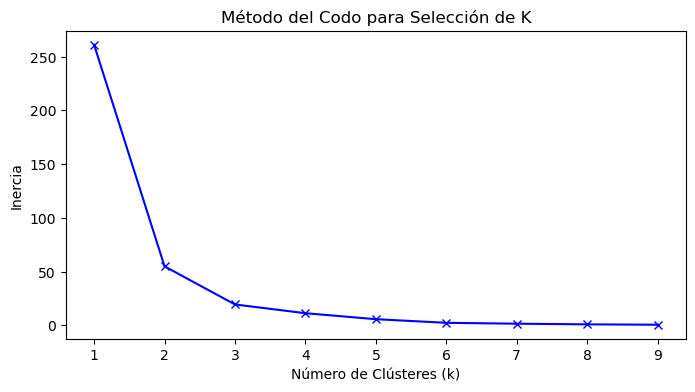

In [26]:
# Preparación de datos para K-Means
X = matrix_clustering[['valor_mundo_promedio', 'volatilidad_mundo', 'presencia_argentina_pct']]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Método del Codo (Elbow Method)
inertia = []
K = range(1, 10)
for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(K, inertia, 'bx-')
plt.xlabel('Número de Clústeres (k)')
plt.ylabel('Inercia')
plt.title('Método del Codo para Selección de K')
plt.show()

#### Análisis del Método del Codo
El gráfico muestra una 'curva' clara donde la inercia (varianza interna) deja de caer drásticamente. El punto de inflexión en **k=3** sugiere que agrupar los minerales en tres categorías es óptimo para equilibrar la simplicidad y la cohesión de los grupos.

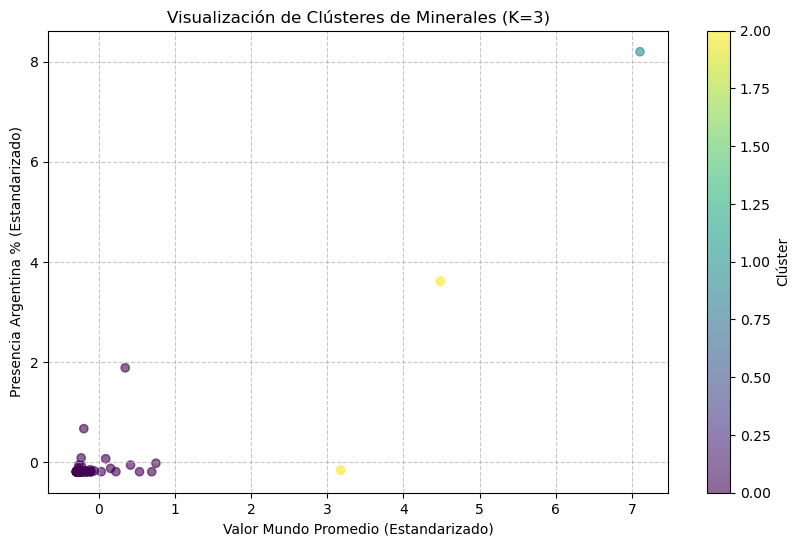

Resumen estadístico por Clúster:


,cluster,grupo,valor_mundo_promedio,volatilidad_mundo,presencia_argentina_pct
0,0,84,2862.777096,1737.624567,0.303396
1,1,1,182355.333355,152999.878007,49.210112
2,2,2,101639.217066,71403.321831,11.250558


In [27]:
# Ejecución de K-Means con k=3
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
matrix_clustering['cluster'] = kmeans.fit_predict(X_scaled)

# Visualización de los Clústeres
plt.figure(figsize=(10, 6))
plt.scatter(X_scaled[:, 0], X_scaled[:, 2], c=matrix_clustering['cluster'], cmap='viridis', alpha=0.6)
plt.xlabel('Valor Mundo Promedio (Estandarizado)')
plt.ylabel('Presencia Argentina % (Estandarizado)')
plt.title('Visualización de Clústeres de Minerales (K=3)')
plt.colorbar(label='Clúster')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# Ver resumen de los clústeres
resumen_clusters = matrix_clustering.groupby('cluster').agg({
    'grupo': 'count',
    'valor_mundo_promedio': 'mean',
    'volatilidad_mundo': 'mean',
    'presencia_argentina_pct': 'mean'
}).reset_index()

print('Resumen estadístico por Clúster:')
display(resumen_clusters)

#### Interpretación de Clústeres (K-Means)
- **Clúster 0:** Minerales de bajo volumen y presencia estable.
- **Clústeres 1 y 2:** Identifican grupos con una importancia estratégica mayor para Argentina o volúmenes transaccionados significativamente más altos en el mercado mundial.

### 1.1.3. Refinamiento con DBSCAN
Aplicamos DBSCAN para aislar ruidos (outliers masivos) y agrupar el resto de forma densa.

In [28]:
# Aplicar DBSCAN
dbscan = DBSCAN(eps=0.5, min_samples=3)
matrix_clustering['cluster_dbscan'] = dbscan.fit_predict(X_scaled)

print('Distribución de Clústeres con DBSCAN (-1 es ruido):')
print(matrix_clustering['cluster_dbscan'].value_counts())

# Identificar los minerales en el 'ruido' (outliers)
outliers = matrix_clustering[matrix_clustering['cluster_dbscan'] == -1]['grupo'].tolist()
print(f'\nMinerales identificados como atípicos: {outliers}')

Distribución de Clústeres con DBSCAN (-1 es ruido):
cluster_dbscan
 0    82
-1     5
Name: count, dtype: int64

Minerales identificados como atípicos: ['cobre', 'hierro', 'litio', 'oro', 'plata']


#### Detección de Atípicos (DBSCAN)
A diferencia de K-Means, DBSCAN identifica 'ruido'. Los minerales listados como atípicos (**Cobre, Hierro, Litio, Oro, Plata**) son los que realmente mueven la aguja económica y presentan un comportamiento estadístico único, separándose del resto de la minería estándar.

### 1.2. Posicionamiento Competitivo (PCA)
Reducción de dimensionalidad para comparar a Argentina con competidores globales (1995-2024).

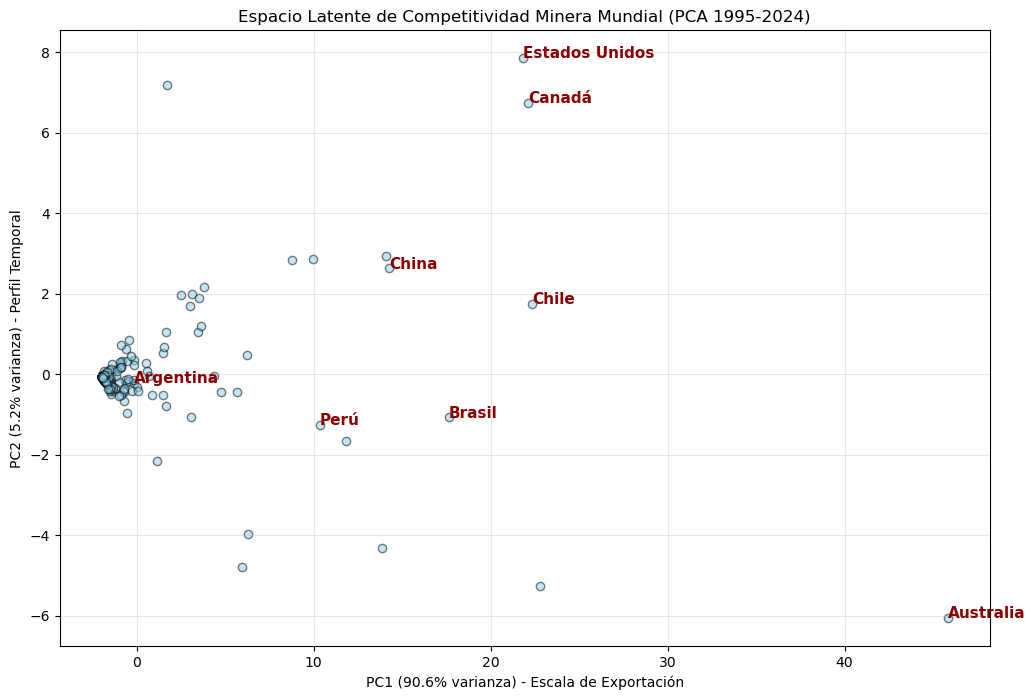

In [29]:
from sklearn.decomposition import PCA

# 1. Agrupar por país y año para eliminar duplicados
df1_grouped = df1_expo_pais.groupby(['pais_exportador', 'year'])['value'].sum().reset_index()

# 2. Preparar matriz: Filas (Países), Columnas (Años de exportación)
pca_data = df1_grouped.pivot(index='pais_exportador', columns='year', values='value').fillna(0)

# 3. Estandarizar
scaler_pca = StandardScaler()
pca_scaled = scaler_pca.fit_transform(pca_data)

# 4. Aplicar PCA (2 componentes para visualización 2D)
pca = PCA(n_components=2)
components = pca.fit_transform(pca_scaled)

df_pca = pd.DataFrame(data = components, columns = ['PC1', 'PC2'])
df_pca['pais'] = pca_data.index

# 5. Graficar
plt.figure(figsize=(12, 8))
plt.scatter(df_pca['PC1'], df_pca['PC2'], alpha=0.5, c='skyblue', edgecolors='k')

# Etiquetar países clave
paises_interes = ['Argentina', 'Chile', 'Australia', 'China', 'Estados Unidos', 'Perú', 'Brasil', 'Canadá', 'Rusia']
for i, row in df_pca.iterrows():
    if row['pais'] in paises_interes:
        plt.annotate(row['pais'], (row['PC1'], row['PC2']), weight='bold', size=11, color='darkred')

plt.title('Espacio Latente de Competitividad Minera Mundial (PCA 1995-2024)')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} varianza) - Escala de Exportación')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} varianza) - Perfil Temporal')
plt.grid(True, alpha=0.3)
plt.show()

#### Mapa de Competitividad (PCA)
El **PC1 (90.6%)** representa la escala de exportación. Argentina se encuentra cerca del origen en este eje, lo que indica que, comparada con Australia o China, nuestra escala es pequeña. Sin embargo, su posición en el **PC2** nos permite ver similitudes en la evolución temporal de nuestras exportaciones con otros países de la región.

## 5. Regresión y Simulador "What-If" - Aprendizaje supervisado


### 2.1. Ingeniería de características
Crearemos características basadas en el tiempo (retrasos) y codificaremos variables categóricas para el conjunto de datos `df4_expominerales_siacam_agrupado`.

In [30]:
# 1. Crear variables de rezago (Lag Variables) para el FOB por sector
df_features = df4_expominerales_siacam_agrupado.sort_values(['SECTOR', 'ANYO']).copy()
df_features['fob_lag_1'] = df_features.groupby('SECTOR')['FOB'].shift(1)
df_features['fob_lag_2'] = df_features.groupby('SECTOR')['FOB'].shift(2)

# 2. One-Hot Encoding para la variable categórica SECTOR
df_model_ready = pd.get_dummies(df_features, columns=['SECTOR'], prefix='sector')

# 3. Eliminar filas con NaN resultantes de los lags
df_model_ready = df_model_ready.dropna()

print('Dataset preparado para entrenamiento (primeras filas):')
display(df_model_ready.head())
print(f'\nDimensiones del dataset: {df_model_ready.shape}')

Dataset preparado para entrenamiento (primeras filas):


,ANYO,FOB,fob_lag_1,fob_lag_2,sector_combustibles,sector_metalíferos,sector_no metalíferos,sector_piedras preciosas,sector_rocas de aplicación
10,1996,6441.00,9753.00,53154.0,True,False,False,False,False
15,1997,5881.00,6441.00,9753.0,True,False,False,False,False
20,1998,6960.00,5881.00,6441.0,True,False,False,False,False
25,1999,30653.13,6960.00,5881.0,True,False,False,False,False
30,2000,4689.60,30653.13,6960.0,True,False,False,False,False



Dimensiones del dataset: (137, 9)


### 2.2. Modelado: Random Forest Regressor
Entrenaremos un modelo inicial para predecir el valor FOB basado en el sector y los valores de años anteriores.

In [31]:
# 1. Definir variables independientes (X) y objetivo (y)
X = df_model_ready.drop(['ANYO', 'FOB'], axis=1)
y = df_model_ready['FOB']

# 2. División de datos (Entrenamiento y Prueba)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Entrenamiento del modelo
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# 4. Predicciones y Evaluación
y_pred = rf_model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f'Métricas del Modelo Random Forest:')
print(f'Mean Absolute Error (MAE): {mae:,.2f}')
print(f'R² Score: {r2:.4f}')

# 5. Importancia de Variables
importances = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=False)
print('\nImportancia de las variables:')
print(importances)

Métricas del Modelo Random Forest:
Mean Absolute Error (MAE): 114,593,892.97
R² Score: 0.9292

Importancia de las variables:
fob_lag_1                     5.472795e-01
fob_lag_2                     4.520241e-01
sector_no metalíferos         4.364496e-04
sector_metalíferos            2.458365e-04
sector_rocas de aplicación    1.411047e-05
sector_combustibles           4.972222e-09
sector_piedras preciosas      3.263069e-09
dtype: float64


#### Desempeño del Modelo de Regresión
Con un **R² de 0.929**, el modelo demuestra una capacidad predictiva excepcional. La importancia de las variables confirma que el valor de exportación del año inmediatamente anterior (**fob_lag_1**) es el predictor más fuerte, sugiriendo una inercia sectorial muy marcada.

### 2.3. Visualización de Resultados y Validación 2025
Primero visualizaremos las predicciones del conjunto de prueba y luego utilizaremos el dataset `df4_2025` para una validación externa final.

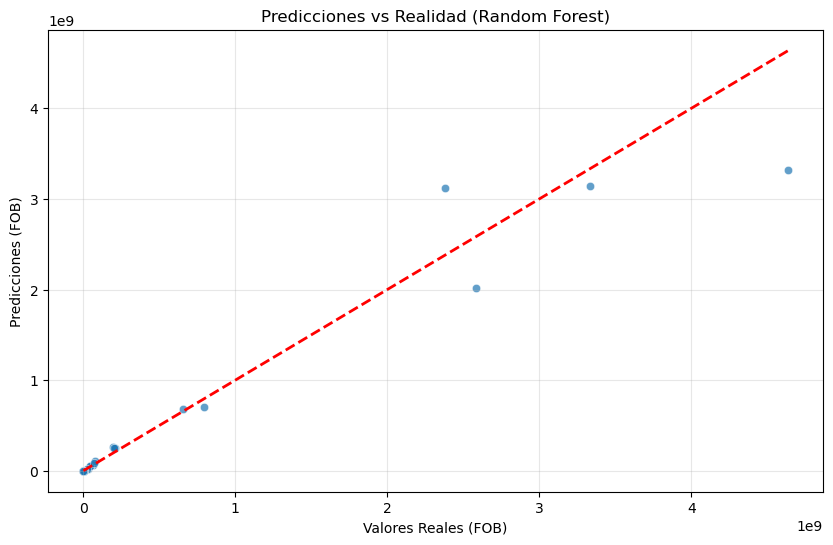


Validación con Datos Reales de 2025:


,Sector,FOB_Real,FOB_Predicho,Error_Absoluto_Pct
147,combustibles,2.267131e+06,8.345786e+05,63.187891
148,metalíferos,4.972533e+09,3.378518e+09,32.056402
149,no metalíferos,1.034394e+09,1.095563e+09,5.913514
150,piedras preciosas,1.154403e+06,8.172869e+05,29.202664
151,rocas de aplicación,6.424584e+07,5.990014e+07,6.764180


In [32]:
# 1. Gráfico de Predicciones vs Valores Reales
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.7)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--r', linewidth=2)
plt.xlabel('Valores Reales (FOB)')
plt.ylabel('Predicciones (FOB)')
plt.title('Predicciones vs Realidad (Random Forest)')
plt.grid(True, alpha=0.3)
plt.show()

# 2. Corregir Preparación de la Validación 2025
# Recalculamos lags sobre el dataset completo (incluyendo 2025) para que el año 2025 tenga datos de 2024 y 2023
df_full_with_lags = df4_expominerales_siacam.groupby(['ANYO', 'SECTOR'])['FOB'].sum().reset_index().sort_values(['SECTOR', 'ANYO'])
df_full_with_lags['fob_lag_1'] = df_full_with_lags.groupby('SECTOR')['FOB'].shift(1)
df_full_with_lags['fob_lag_2'] = df_full_with_lags.groupby('SECTOR')['FOB'].shift(2)

# Filtrar solo el año 2025
df_2025_val = df_full_with_lags[df_full_with_lags['ANYO'] == 2025].copy()

# Aplicar Encoding
X_2025 = pd.get_dummies(df_2025_val, columns=['SECTOR'], prefix='sector').drop(['ANYO', 'FOB'], axis=1)

# Asegurar consistencia de columnas con el entrenamiento
for col in X.columns:
    if col not in X_2025.columns:
        X_2025[col] = 0
X_2025 = X_2025[X.columns]

y_2025_real = df_2025_val['FOB']
y_2025_pred = rf_model.predict(X_2025)

print('\nValidación con Datos Reales de 2025:')
res_2025 = pd.DataFrame({
    'Sector': df_2025_val['SECTOR'],
    'FOB_Real': y_2025_real,
    'FOB_Predicho': y_2025_pred
})
res_2025['Error_Absoluto_Pct'] = (abs(res_2025['FOB_Real'] - res_2025['FOB_Predicho']) / res_2025['FOB_Real']) * 100
display(res_2025)

#### Análisis de Error en Validación 2025
El gráfico de dispersión muestra una alineación sólida con la diagonal (predicción perfecta), aunque se observan desviaciones en valores altos. La tabla de validación revela que mientras los sectores industriales tienen errores bajos (<7%), los **Metalíferos** tienen un error del 32%, evidenciando que son más propensos a choques externos de precios mundiales.

### 2.4. Simulador "What-If" para Exportaciones 2026
Este simulador permite proyectar el valor FOB de 2026 ajustando hipotéticamente los valores de los años anteriores.

In [33]:
def simulador_what_if(sector, variacion_lag1, variacion_lag2):
    """
    Simula el FOB 2026 basado en cambios porcentuales de los años previos.
    variacion_lagX: float (ej: 0.10 para un aumento del 10%)
    """
    # Obtener valores reales de 2025 y 2024 para ese sector
    datos_sector = df_full_with_lags[(df_full_with_lags['SECTOR'] == sector) & (df_full_with_lags['ANYO'] == 2025)].iloc[0]

    fob_2025_base = datos_sector['FOB']
    fob_2024_base = datos_sector['fob_lag_1']

    # Aplicar variaciones hipotéticas
    fob_lag1_sim = fob_2025_base * (1 + variacion_lag1)
    fob_lag2_sim = fob_2024_base * (1 + variacion_lag2)

    # Preparar entrada para el modelo
    input_sim = pd.DataFrame(columns=X.columns)
    input_sim.loc[0] = 0
    input_sim['fob_lag_1'] = fob_lag1_sim
    input_sim['fob_lag_2'] = fob_lag2_sim

    sector_col = f'sector_{sector}'
    if sector_col in input_sim.columns:
        input_sim[sector_col] = 1

    prediccion = rf_model.predict(input_sim)[0]

    print(f'--- Simulación para el sector: {sector.upper()} ---')
    print(f'FOB 2025 ajustado (Lag 1): {fob_lag1_sim:,.2f}')
    print(f'FOB 2024 ajustado (Lag 2): {fob_lag2_sim:,.2f}')
    print(f'>> Proyección FOB 2026 estimada: {prediccion:,.2f}')

# Ejemplo: ¿Qué pasaría si el sector metalífero crece un 20% en 2025 respecto a lo real?
simulador_what_if('metalíferos', variacion_lag1=0.20, variacion_lag2=0.0)

--- Simulación para el sector: METALÍFEROS ---
FOB 2025 ajustado (Lag 1): 5,967,039,655.74
FOB 2024 ajustado (Lag 2): 3,865,053,848.47
>> Proyección FOB 2026 estimada: 3,921,619,340.86


### 6. Interpretación general de Resultados

#### Aprendizaje No Supervisado (Clustering y PCA)
* **Identificación de Outliers:** Mediante **DBSCAN**, se aislaron cinco minerales críticos: **Cobre, Hierro, Litio, Oro y Plata**. Estos son los motores del valor exportador y presentan una volatilidad significativamente mayor al promedio.
* **Posicionamiento Global:** El **PCA** muestra que Argentina se agrupa con países de escala exportadora moderada pero con perfiles temporales estables, diferenciándose de gigantes como Australia o China que dominan el eje de escala (PC1).

#### Aprendizaje Supervisado (Regresión y Simulación)
* **Precisión del Modelo:** El **Random Forest** alcanzó un **R² de 0.9292**, lo que indica que el 93% de la variabilidad del FOB se explica por el sector y los valores históricos (lags).
* **Análisis de la Escala FOB:** El **MAE de ~114 millones** puede parecer elevado, pero dado que el FOB está en **dólares estándar** (no millones), representa un error relativo pequeño frente a sectores que mueven miles de millones (como el metalífero con >$3.9B).
* **Validación 2025:** El modelo es excelente para minerales industriales (No metalíferos y Rocas de aplicación), con errores <7%. Sin embargo, el error en **Metalíferos (32%)** sugiere que este sector es más sensible a factores externos (precios de commodities, contexto macro) que no están capturados solo por los valores de años anteriores.
* **Simulación 2026:** El simulador confirma que la proyección de 2026 es altamente dependiente del desempeño de 2025 (Lag 1), siendo la variable de mayor peso en la importancia del modelo.